In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from xgboost import XGBClassifier

# ============================================================
# 1. LOAD & PREPARE DATA
# ============================================================
df_train = pd.read_csv("https://raw.githubusercontent.com/marcojs253-crypto/P_2/refs/heads/main/Data/TrainingData.csv")

# Fjern irrelevante features
irrelevant_cols = ["filnavn", "beta", "snr_db"]
for col in irrelevant_cols:
    if col in df_train.columns:
        df_train = df_train.drop(columns=[col])

# ============================================================
# 2. FILTERING
# ============================================================
# df_train = df_train[...].copy()
# df_train = df_train.dropna(subset=["kolonneNavn"])

# ============================================================
# 3. FEATURES & TARGET
# ============================================================
X = df_train.drop(columns=["target"])
y = df_train["target"]

# Fast klasse-mapping i den ønskede rækkefølge
target_names = [
    "BlueNoise",
    "BrownNoise",
    "Clean",
    "PinkNoise",
    "VioletNoise",
    "WhiteNoise",
]
class_mapping = {name: idx for idx, name in enumerate(target_names)}

unknown_labels = sorted(set(y.unique()) - set(class_mapping.keys()))
if unknown_labels:
    raise ValueError(f"Ukendte klasser i target: {unknown_labels}")

y_encoded = y.map(class_mapping).astype(int)

# LabelEncoder beholdes for kompatibilitet med senere celler
label_encoder = LabelEncoder()
label_encoder.fit(target_names)

print("Klasse mapping:")
for class_name in target_names:
    print(f"{class_name} -> {class_mapping[class_name]}")

# ============================================================
# 4. TRAIN / VALIDATION SPLIT
# ============================================================
X_train, X_val, y_train, y_val = train_test_split(
    X, y_encoded, test_size=0.20, stratify=y_encoded, random_state=42
)

# ============================================================
# 5. 5-FOLD CV + GRID SEARCH (XGBOOST, SAMLET MODEL)
# ============================================================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_grid = {
    "n_estimators": [100, 150, 200, 250, 300],
    "max_depth": [3, 5, 7, 9, 11],
    "learning_rate": [0.01, 0.03, 0.1, 0.2],
    "subsample": [0.8, 1.0, 1.2, 1.4, 1.6],
    "colsample_bytree": [0.8, 1.0, 1.2, 1.4],
}

grid_combinations = (
    len(param_grid["n_estimators"]) *
    len(param_grid["max_depth"]) *
    len(param_grid["learning_rate"]) *
    len(param_grid["subsample"]) *
    len(param_grid["colsample_bytree"])
 )
print(f"Grid-kombinationer: {grid_combinations}")
print(f"Model fits i alt (kombinationer x 5 folds): {grid_combinations * 5}")

base_model = XGBClassifier(
    objective="multi:softprob",
    num_class=len(target_names),
    random_state=42,
    eval_metric="mlogloss",
    tree_method="hist"
 )

search = GridSearchCV(
    estimator=base_model,
    param_grid=param_grid,
    scoring="accuracy",
    cv=cv,
    n_jobs=-1,
    verbose=0
)

search.fit(X_train, y_train)

print(f"Best CV Accuracy (5-fold): {search.best_score_:.4f}")
print(f"Best params: {search.best_params_}")

best_idx = search.best_index_
best_fold_scores = [search.cv_results_[f"split{i}_test_score"][best_idx] for i in range(cv.n_splits)]
print("Fold accuracies for bedste model:")
for i, score in enumerate(best_fold_scores, start=1):
    print(f"Fold {i}: {score:.4f}")
print(f"Mean af fold accuracies: {np.mean(best_fold_scores):.4f}")

model = search.best_estimator_
y_val_pred = model.predict(X_val)

print(f"\nValidation Accuracy: {accuracy_score(y_val, y_val_pred):.4f}")
print("\nClassification Report (Validation):")
print(classification_report(y_val, y_val_pred, target_names=target_names, digits=4))

print("\nConfusion Matrix (Validation):")
print(confusion_matrix(y_val, y_val_pred))

Klasse mapping:
BlueNoise -> 0
BrownNoise -> 1
Clean -> 2
PinkNoise -> 3
VioletNoise -> 4
WhiteNoise -> 5
Grid-kombinationer: 72
Model fits i alt (kombinationer x 5 folds): 360
Best CV Accuracy (5-fold): 0.9547
Best params: {'colsample_bytree': 0.8, 'learning_rate': 0.03, 'max_depth': 5, 'n_estimators': 300, 'subsample': 0.8}
Fold accuracies for bedste model:
Fold 1: 0.9578
Fold 2: 0.9184
Fold 3: 0.9637
Fold 4: 0.9637
Fold 5: 0.9698
Mean af fold accuracies: 0.9547

Validation Accuracy: 0.9614

Classification Report (Validation):
              precision    recall  f1-score   support

   BlueNoise     0.9437    0.9710    0.9571        69
  BrownNoise     0.9054    0.9710    0.9371        69
       Clean     0.9545    0.9130    0.9333        69
   PinkNoise     1.0000    0.9855    0.9927        69
 VioletNoise     0.9706    0.9565    0.9635        69
  WhiteNoise     1.0000    0.9710    0.9853        69

    accuracy                         0.9614       414
   macro avg     0.9624    0.96

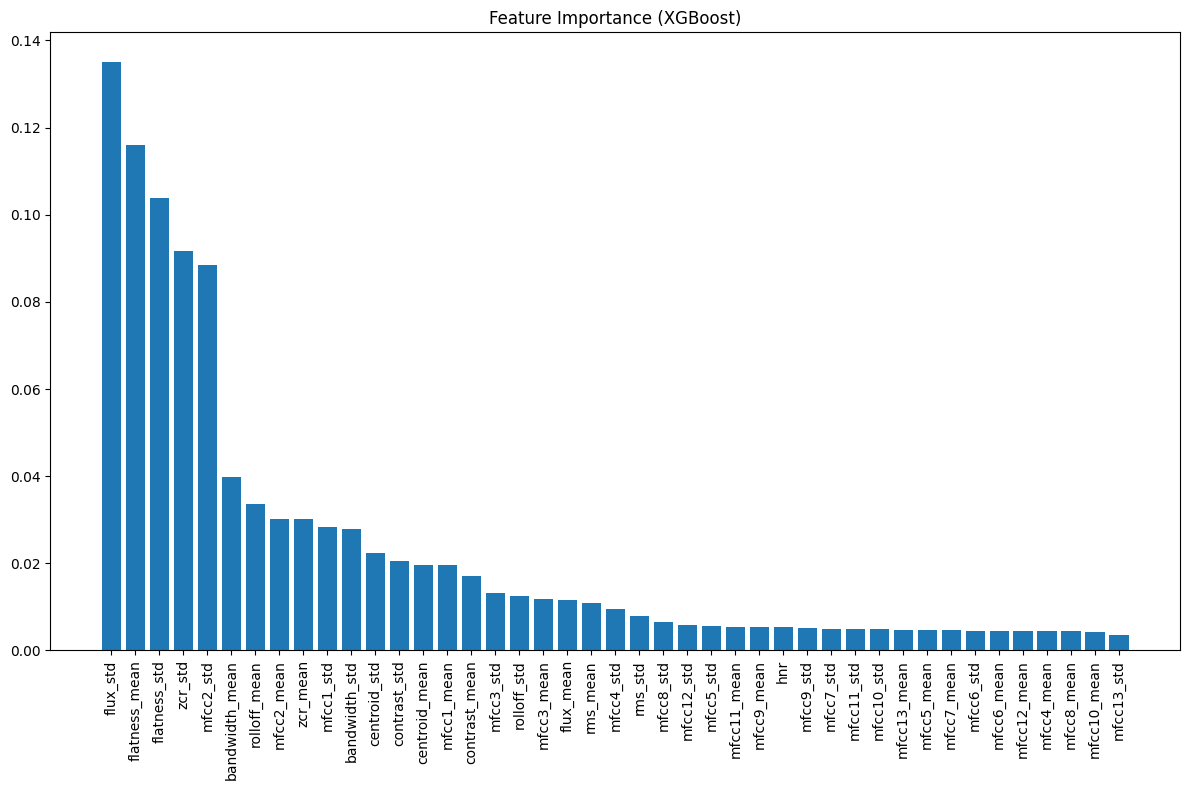


Top 15 vigtigste features:
flux_std: 0.1351
flatness_mean: 0.1160
flatness_std: 0.1038
zcr_std: 0.0918
mfcc2_std: 0.0885
bandwidth_mean: 0.0398
rolloff_mean: 0.0337
mfcc2_mean: 0.0302
zcr_mean: 0.0301
mfcc1_std: 0.0284
bandwidth_std: 0.0279
centroid_std: 0.0224
contrast_std: 0.0205
centroid_mean: 0.0196
mfcc1_mean: 0.0196


In [ ]:
# ----------------------------
# 4. FEATURE IMPORTANCE
# ----------------------------

# Henter hvor vigtig hver feature er i den trænede XGBoost-model
importances = model.feature_importances_

# Gemmer navnene på alle features (kolonnenavne fra datasættet)
feature_names = X.columns

# Sorterer features efter importance (størst først)
indices = np.argsort(importances)[::-1]

# Opretter en figur til plot
plt.figure(figsize=(12, 8))

# Titel på grafen
plt.title("Feature Importance (XGBoost)")

# Barplot der viser importance for alle features
plt.bar(range(len(importances)), importances[indices])

# Sætter feature-navne på x-aksen og roterer dem så de kan læses
plt.xticks(range(len(importances)), feature_names[indices], rotation=90)

# Tilpasser layout så labels ikke overlapper
plt.tight_layout()

# Viser grafen
plt.show()

# Printer de 15 vigtigste features i konsollen
print("\nTop 15 vigtigste features:")
for i in indices[:15]:
    print(f"{feature_names[i]}: {importances[i]:.4f}")

Keeping 20 / 43 features
Removed features: 23
Optimal importance_threshold: 0.011367
Baseline Validation Accuracy: 0.9614
Best Validation Accuracy: 0.9638 (+0.0024 vs baseline)


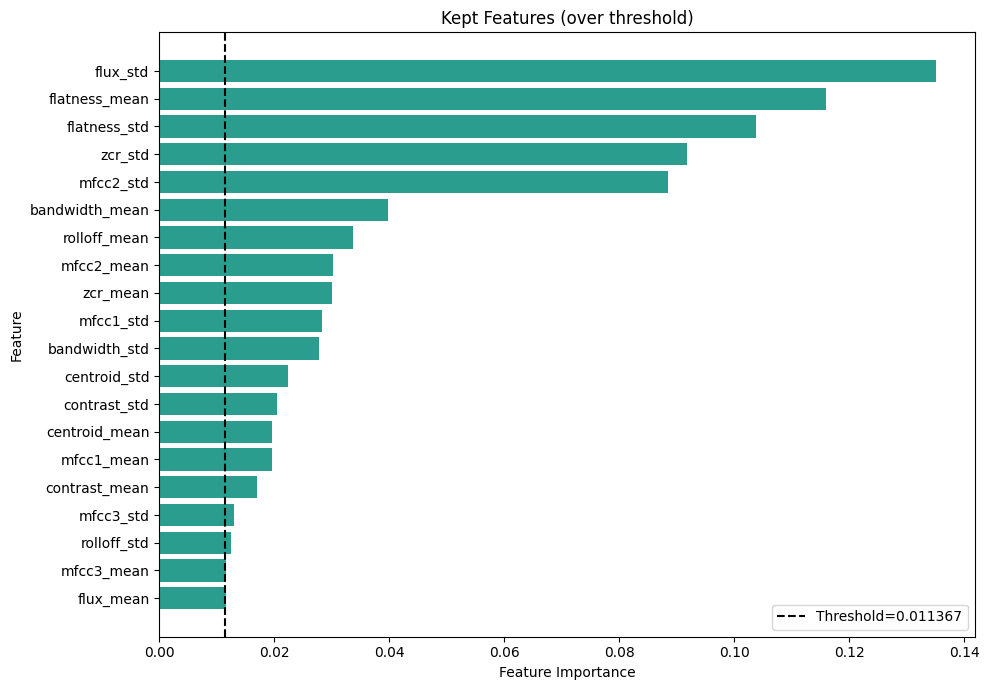

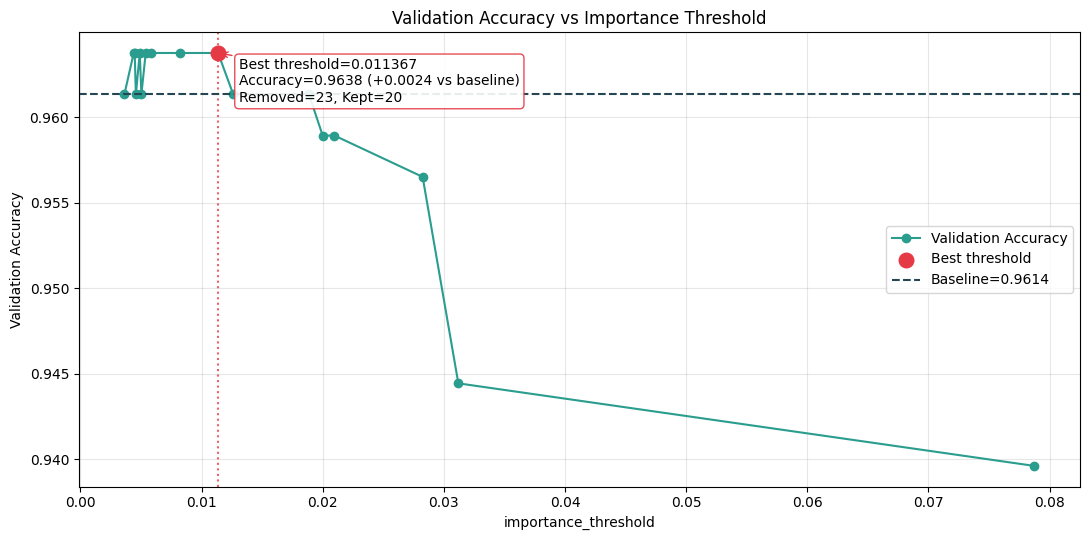

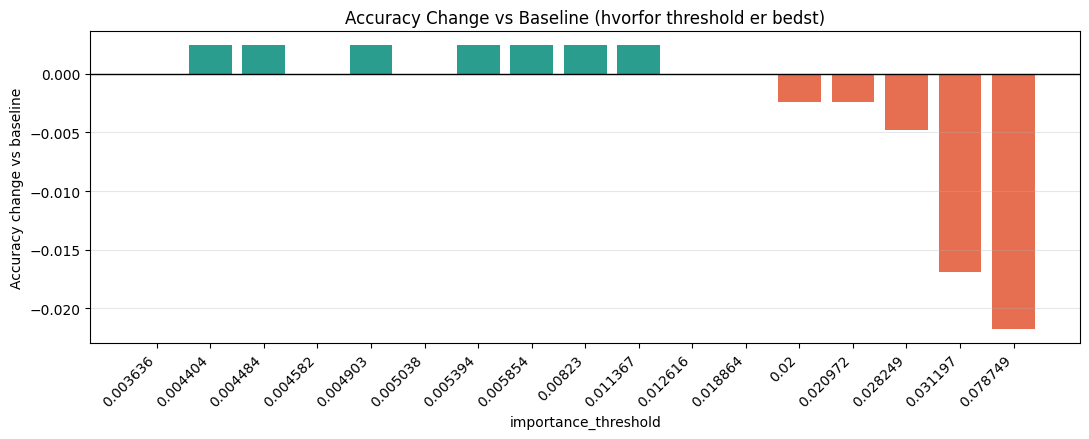

Features kept at best threshold: 20
Features removed at best threshold: 23


In [ ]:
# ----------------------------
# 5. FEATURE SELECTION
# ----------------------------

# Baseline accuracy fra modellen der bruger ALLE features
baseline_val_acc = accuracy_score(y_val, y_val_pred)

# Opretter en dataframe med feature navn og importance
importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=True).reset_index(drop=True)

# Genererer forskellige mulige threshold-værdier til feature selection
# (fra 0 til 0.9 i 16 trin)
q_values = np.linspace(0.0, 0.9, 16)

# Finder importance værdier baseret på kvantiler
candidate_thresholds = sorted(
    set(np.quantile(importances, q_values).round(6).tolist() + [0.02])
)

# Liste til at gemme resultater fra hver threshold test
threshold_results = []

# Tester hver threshold
for thr in candidate_thresholds:

    # Beholder kun features der har importance over threshold
    kept = [
        feature
        for feature, importance in zip(feature_names, importances)
        if importance >= thr
    ]

    # Hvis ingen features er tilbage, springes denne threshold over
    if len(kept) < 1:
        continue

    # Reducerer trænings- og validationsdatasæt til kun de udvalgte features
    X_train_thr = X_train[kept]
    X_val_thr = X_val[kept]

    # Opretter en ny XGBoost-model med samme hyperparametre som den bedste model
    thr_model = XGBClassifier(
        objective="multi:softprob",
        num_class=len(target_names),
        random_state=42,
        eval_metric="mlogloss",
        tree_method="hist",
        **search.best_params_
    )

    # Træner modellen med de reducerede features
    thr_model.fit(X_train_thr, y_train)

    # Laver prediction på validation data
    thr_pred = thr_model.predict(X_val_thr)

    # Beregner accuracy for denne threshold
    thr_acc = accuracy_score(y_val, thr_pred)

    # Gemmer resultatet
    threshold_results.append({
        "threshold": float(thr),      # threshold værdi
        "n_kept": int(len(kept)),     # antal features beholdt
        "n_removed": int(len(feature_names) - len(kept)),  # antal fjernet
        "val_acc": float(thr_acc),    # validation accuracy
    })


# Hvis ingen thresholds kunne evalueres stoppes programmet
if not threshold_results:
    raise ValueError("Kunne ikke evaluere nogen threshold-kandidater.")

# Konverterer resultater til dataframe
results_df = pd.DataFrame(threshold_results)

# Beregner forskellen mellem baseline accuracy og ny accuracy
results_df["delta_vs_baseline"] = results_df["val_acc"] - baseline_val_acc

# Finder den bedste threshold baseret på:
# 1. højeste accuracy
# 2. færrest features
best_row = results_df.sort_values(
    ["val_acc", "n_kept", "threshold"],
    ascending=[False, True, True]
).iloc[0]

# Gemmer den bedste threshold
importance_threshold = float(best_row["threshold"])

# Liste over features der beholdes
features_to_keep = [
    feature
    for feature, importance in zip(feature_names, importances)
    if importance >= importance_threshold
]

# Liste over features der fjernes
removed_features = [
    feature
    for feature, importance in zip(feature_names, importances)
    if importance < importance_threshold
]

# Nyt datasæt med kun de vigtigste features
X_reduced = X[features_to_keep]

# Gemmer bedste accuracy
best_acc = float(best_row["val_acc"])

# Forskel i accuracy i forhold til baseline
delta_best = best_acc - baseline_val_acc

# Udskriver resultater
print(f"Keeping {len(features_to_keep)} / {len(feature_names)} features")
print(f"Removed features: {len(removed_features)}")
print(f"Optimal importance_threshold: {importance_threshold:.6f}")
print(f"Baseline Validation Accuracy: {baseline_val_acc:.4f}")
print(f"Best Validation Accuracy: {best_acc:.4f} ({delta_best:+.4f} vs baseline)")


# Plot af de features der er tilbage efter threshold
if features_to_keep:

    kept_df = importance_df[importance_df["importance"] >= importance_threshold]

    plt.figure(figsize=(10, max(4, len(kept_df) * 0.35)))

    # Horisontalt barplot af feature importance
    plt.barh(kept_df["feature"], kept_df["importance"], color="#2a9d8f")

    # Lodret linje der viser threshold
    plt.axvline(
        importance_threshold,
        color="black",
        linestyle="--",
        label=f"Threshold={importance_threshold}"
    )

    plt.title("Kept Features (over threshold)")
    plt.xlabel("Feature Importance")
    plt.ylabel("Feature")
    plt.legend()
    plt.tight_layout()
    plt.show()

else:
    print("Ingen features er tilbage ved nuværende threshold.")


# ----------------------------
# Accuracy vs threshold graf
# ----------------------------

plot_df = results_df.sort_values("threshold").copy()

best_threshold = float(best_row["threshold"])
best_removed = int(best_row["n_removed"])
best_kept = int(best_row["n_kept"])

plt.figure(figsize=(11, 5.5))

# Plot accuracy for hver threshold
plt.plot(
    plot_df["threshold"],
    plot_df["val_acc"],
    marker="o",
    color="#2a9d8f",
    label="Validation Accuracy"
)

# Marker bedste threshold
plt.scatter(
    [best_threshold],
    [best_acc],
    color="#e63946",
    s=110,
    zorder=5,
    label="Best threshold"
)

# Lodret linje ved bedste threshold
plt.axvline(best_threshold, color="#e63946", linestyle=":", alpha=0.8)

# Baseline accuracy linje
plt.axhline(
    baseline_val_acc,
    color="#264653",
    linestyle="--",
    label=f"Baseline={baseline_val_acc:.4f}"
)

plt.title("Validation Accuracy vs Importance Threshold")
plt.xlabel("importance_threshold")
plt.ylabel("Validation Accuracy")
plt.grid(alpha=0.3)

# Note der forklarer bedste threshold
note = (
    f"Best threshold={best_threshold:.6f}\n"
    f"Accuracy={best_acc:.4f} ({delta_best:+.4f} vs baseline)\n"
    f"Removed={best_removed}, Kept={best_kept}"
)

plt.annotate(
    note,
    xy=(best_threshold, best_acc),
    xytext=(15, -35),
    textcoords="offset points",
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#e63946", alpha=0.9),
    arrowprops=dict(arrowstyle="->", color="#e63946")
)

plt.legend()
plt.tight_layout()
plt.show()


# ----------------------------
# Accuracy change plot
# ----------------------------

plt.figure(figsize=(11, 4.5))

# Farve grøn hvis accuracy er bedre end baseline ellers rød
colors = ["#2a9d8f" if d >= 0 else "#e76f51" for d in plot_df["delta_vs_baseline"]]

plt.bar(
    plot_df["threshold"].astype(str),
    plot_df["delta_vs_baseline"],
    color=colors
)

plt.axhline(0, color="black", linewidth=1)

plt.title("Accuracy Change vs Baseline (hvorfor threshold er bedst)")
plt.xlabel("importance_threshold")
plt.ylabel("Accuracy change vs baseline")

plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# Printer hvor mange features der blev beholdt/fjernet
print(f"Features kept at best threshold: {best_kept}")
print(f"Features removed at best threshold: {best_removed}")